In [2]:
import os
import shutil
import pandas as pd
import matplotlib.pyplot as plt
import keras
import keras_tuner as kt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:
# 1. GENERATE AND PREPROCESS DATA (Mandatory for a new file)

x, y = make_classification(n_samples=2000, n_features=15, random_state=42)

# Fix the DataFrame initialization we corrected earlier
Data = pd.DataFrame(x, columns=[f"feature_{i}" for i in range(x.shape[1])])
Data["target"] = y

# Split data into training and testing sets
X_train, X_test, Y_train, Y_test = train_test_split(x, y, test_size=0.20, random_state=42)

# Scale features to prevent gradients from exploding
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [4]:
# 2. DEFINE THE TUNING MODEL FUNCTION
# =====================================================================
def build_one_specific_model(hp):
    model = keras.Sequential([
        # Tunable Dense Layer
        keras.layers.Dense(
            units=hp.Int("units", min_value=10, max_value=32, step=5),
            activation=hp.Choice("activation", ["relu", "tanh"]),
            input_shape=(15,)
        ),
        # Tunable Dropout Layer
        keras.layers.Dropout(rate=hp.Float("dropout", 0.1, 0.5, step=0.2)),
        
        # Static Output Layer for Binary Classification
        keras.layers.Dense(1, activation="sigmoid")
    ])
    
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return model


In [5]:
# 3. INITIALIZE AND EXECUTE THE TUNER
# =====================================================================
# Wipe out any old folder structures to clear the workspace cache cleanly
if os.path.exists("tuning_only_workspace"):
    shutil.rmtree("tuning_only_workspace")

tuner = kt.RandomSearch(
    build_one_specific_model,
    objective="val_accuracy",
    max_trials=3,
    directory="tuning_only_workspace",
    overwrite=True
)

# Start the automated search loop
print("\n--- Starting Hyperparameter Search ---")
tuner.search(X_train, Y_train, epochs=5, validation_split=0.10)


Trial 3 Complete [00h 00m 04s]
val_accuracy: 0.856249988079071

Best val_accuracy So Far: 0.862500011920929
Total elapsed time: 00h 00m 14s


In [6]:
# 4. PRINT WINNING PARAMETERS
# =====================================================================
best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]
print("\n--- BEST HYPERPARAMETERS FOUND ---")
print("Optimal Units:    ", best_hp.get("units"))
print("Optimal Activation:", best_hp.get("activation"))
print("Optimal Dropout:   ", best_hp.get("dropout"))


--- BEST HYPERPARAMETERS FOUND ---
Optimal Units:     15
Optimal Activation: tanh
Optimal Dropout:    0.5


In [8]:
# 1. Extract the winning settings from the tuner
best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]

# 2. Build the actual Keras model using those winning settings
best_model = tuner.hypermodel.build(best_hp)

# 3. NOW you can fit and plot!
history = best_model.fit(
    X_train, 
    Y_train, 
    epochs=30,              
    validation_split=0.10,  
    batch_size=4,
    verbose=1
)


Epoch 1/30
360/360 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6250 - loss: 0.6650 - val_accuracy: 0.8438 - val_loss: 0.4195
Epoch 2/30
360/360 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8319 - loss: 0.3775 - val_accuracy: 0.8438 - val_loss: 0.3238
Epoch 3/30
360/360 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8819 - loss: 0.3138 - val_accuracy: 0.8562 - val_loss: 0.3051
Epoch 4/30
360/360 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8868 - loss: 0.2888 - val_accuracy: 0.8625 - val_loss: 0.2992
Epoch 5/30
360/360 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8840 - loss: 0.2884 - val_accuracy: 0.8625 - val_loss: 0.2989
Epoch 6/30
360/360 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8875 - loss: 0.2833 - val_accuracy: 0.8625 - val_loss: 0.2997
Epoch 7/30
360/360 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8972 - loss: 0.2743 - val_accuracy: 0.8625 - val_loss: 0.2994
Epoch 8/30
360/360 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8903 - loss: 0.2737 - val_accuracy: 0.

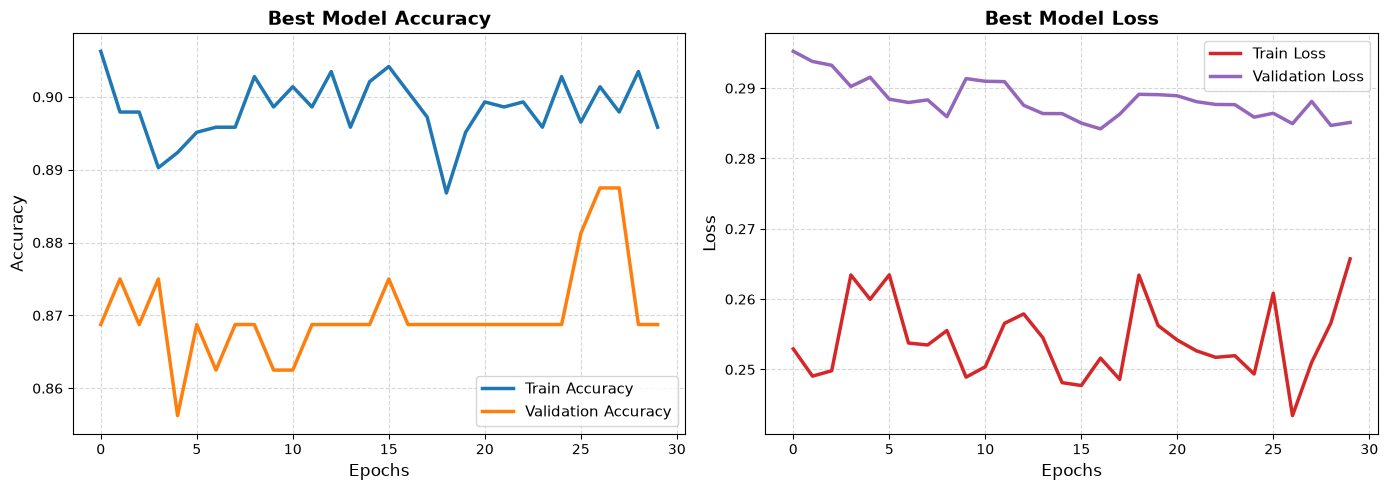

In [10]:
# 2. Set up the canvas for side-by-side graphs
plt.figure(figsize=(14, 5))

# --- PLOT 1: ACCURACY ---
plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train Accuracy", color="#1f77b4", linewidth=2.5)
plt.plot(history.history["val_accuracy"], label="Validation Accuracy", color="#ff7f0e", linewidth=2.5)
plt.title("Best Model Accuracy", fontsize=14, fontweight="bold")
plt.xlabel("Epochs", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle="--", alpha=0.5)

# --- PLOT 2: LOSS ---
plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train Loss", color="#d62728", linewidth=2.5)
plt.plot(history.history["val_loss"], label="Validation Loss", color="#9467bd", linewidth=2.5)
plt.title("Best Model Loss", fontsize=14, fontweight="bold")
plt.xlabel("Epochs", fontsize=12)
plt.ylabel("Loss", fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()
